In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import os
import sys

# Load Data


In [46]:
merged_df = pd.read_csv('data/02-processed/megred_df.csv')

In [47]:
merged_df.head()

,date,brazil_temp_mean,brazil_precip_mean,vietnam_temp_mean,vietnam_precip_mean,coffeeCost,oilCost,cpi,coffeeD,oilD
0,2009-01-01,24.496492,3.236261,21.152823,1.788065,1.165700,41.68,211.143,1.539239,55.036006
1,2009-02-01,24.680386,3.492561,25.691071,1.598750,1.140832,44.76,212.193,1.498947,58.810505
2,2009-03-01,24.709951,3.078186,25.988306,3.845242,1.116909,49.66,212.709,1.463955,65.090369
3,2009-04-01,23.333977,2.792995,27.182500,9.283667,1.159362,51.12,213.240,1.515815,66.837171
4,2009-05-01,21.934531,2.044548,26.795161,11.564113,1.297150,66.31,213.856,1.691082,86.447706


# Missing DATA / DATETIME format

In [48]:
print(merged_df.columns.tolist())
print("\nMissing values per column:")
print(merged_df.isna().sum())

['date', 'brazil_temp_mean', 'brazil_precip_mean', 'vietnam_temp_mean', 'vietnam_precip_mean', 'coffeeCost', 'oilCost', 'cpi', 'coffeeD', 'oilD']

Missing values per column:
date                   0
brazil_temp_mean       0
brazil_precip_mean     0
vietnam_temp_mean      6
vietnam_precip_mean    6
coffeeCost             0
oilCost                0
cpi                    0
coffeeD                0
oilD                   0
dtype: int64


In [49]:
merged_df["date"] = pd.to_datetime(merged_df["date"])
merged_df = merged_df.sort_values("date").reset_index(drop=True)

merged_df[["date"]].head()

,date
0,2009-01-01
1,2009-02-01
2,2009-03-01
3,2009-04-01
4,2009-05-01


# Correlation Heatmap

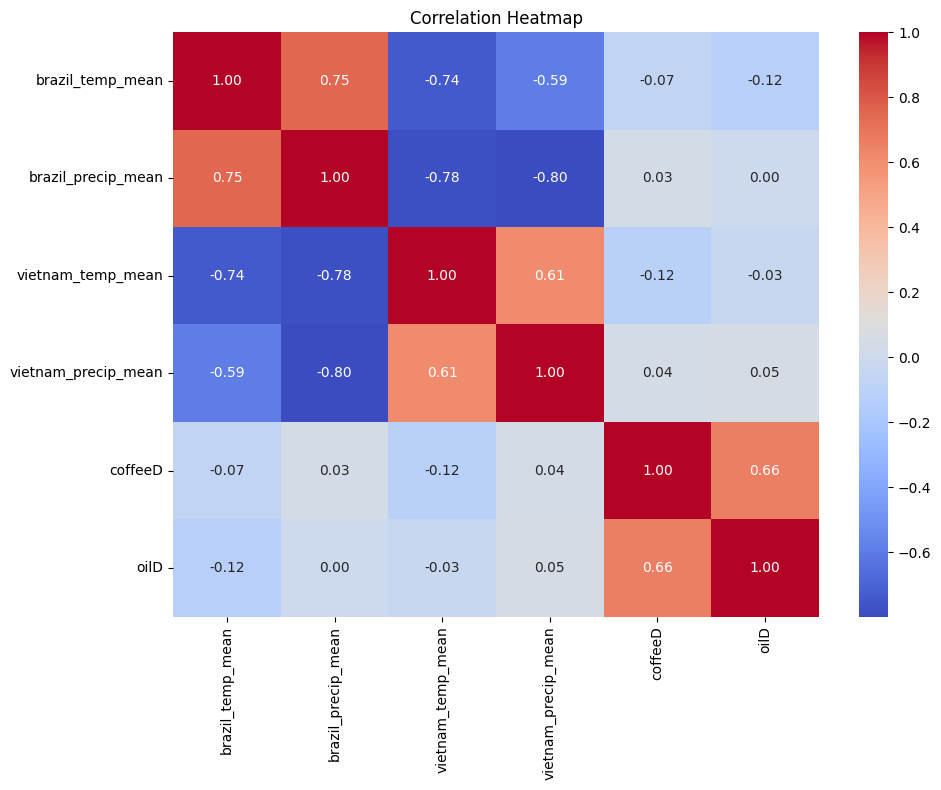

In [50]:
corr_cols = [
    "brazil_temp_mean",
    "brazil_precip_mean",
    "vietnam_temp_mean",
    "vietnam_precip_mean",
  
    "coffeeD",
    "oilD"
]

plt.figure(figsize=(10, 8))
sns.heatmap(merged_df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Add Lag 

In [51]:
df_model = merged_df.copy()

# Oil lags
for lag in [1, 2, 3]:
    df_model[f"oilD_lag{lag}"] = df_model["oilD"].shift(lag)

# Brazil weather lags
for lag in [1, 2, 3]:
    df_model[f"brazil_temp_lag{lag}"] = df_model["brazil_temp_mean"].shift(lag)
    df_model[f"brazil_precip_lag{lag}"] = df_model["brazil_precip_mean"].shift(lag)

# Vietnam weather lags
for lag in [1, 2, 3]:
    df_model[f"vietnam_temp_lag{lag}"] = df_model["vietnam_temp_mean"].shift(lag)
    df_model[f"vietnam_precip_lag{lag}"] = df_model["vietnam_precip_mean"].shift(lag)

df_model.head()

,date,brazil_temp_mean,brazil_precip_mean,vietnam_temp_mean,vietnam_precip_mean,coffeeCost,oilCost,cpi,coffeeD,oilD,...,brazil_temp_lag2,brazil_precip_lag2,brazil_temp_lag3,brazil_precip_lag3,vietnam_temp_lag1,vietnam_precip_lag1,vietnam_temp_lag2,vietnam_precip_lag2,vietnam_temp_lag3,vietnam_precip_lag3
0,2009-01-01,24.496492,3.236261,21.152823,1.788065,1.165700,41.68,211.143,1.539239,55.036006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-02-01,24.680386,3.492561,25.691071,1.598750,1.140832,44.76,212.193,1.498947,58.810505,...,NaN,NaN,NaN,NaN,21.152823,1.788065,NaN,NaN,NaN,NaN
2,2009-03-01,24.709951,3.078186,25.988306,3.845242,1.116909,49.66,212.709,1.463955,65.090369,...,24.496492,3.236261,NaN,NaN,25.691071,1.598750,21.152823,1.788065,NaN,NaN
3,2009-04-01,23.333977,2.792995,27.182500,9.283667,1.159362,51.12,213.240,1.515815,66.837171,...,24.680386,3.492561,24.496492,3.236261,25.988306,3.845242,25.691071,1.598750,21.152823,1.788065
4,2009-05-01,21.934531,2.044548,26.795161,11.564113,1.297150,66.31,213.856,1.691082,86.447706,...,24.709951,3.078186,24.680386,3.492561,27.182500,9.283667,25.988306,3.845242,25.691071,1.598750


In [52]:
df_model["coffee_future"] = df_model["coffeeD"].shift(-1)

In [53]:
feature_cols = [
    "oilD",
    "oilD_lag1",
    "oilD_lag2",
    "oilD_lag3",
    
    "brazil_temp_mean",
    "brazil_precip_mean",
    "vietnam_temp_mean",
    "vietnam_precip_mean",
    
    "brazil_temp_lag1",
    "brazil_precip_lag1",
    "vietnam_temp_lag1",
    "vietnam_precip_lag1",
    
    "brazil_temp_lag2",
    "brazil_precip_lag2",
    "vietnam_temp_lag2",
    "vietnam_precip_lag2",
    
    "brazil_temp_lag3",
    "brazil_precip_lag3",
    "vietnam_temp_lag3",
    "vietnam_precip_lag3",
    

]

target_col = "coffee_future"

In [54]:
df_model = df_model[["date"] + feature_cols + [target_col]].dropna().reset_index(drop=True)

print(df_model.shape)
df_model.head()

(147, 22)


,date,oilD,oilD_lag1,oilD_lag2,oilD_lag3,brazil_temp_mean,brazil_precip_mean,vietnam_temp_mean,vietnam_precip_mean,brazil_temp_lag1,...,vietnam_precip_lag1,brazil_temp_lag2,brazil_precip_lag2,vietnam_temp_lag2,vietnam_precip_lag2,brazil_temp_lag3,brazil_precip_lag3,vietnam_temp_lag3,vietnam_precip_lag3,coffee_future
0,2009-04-01,66.837171,65.090369,58.810505,55.036006,23.333977,2.792995,27.182500,9.283667,24.709951,...,3.845242,24.680386,3.492561,25.691071,1.598750,24.496492,3.236261,21.152823,1.788065,1.691082
1,2009-05-01,86.447706,66.837171,65.090369,58.810505,21.934531,2.044548,26.795161,11.564113,23.333977,...,9.283667,24.709951,3.078186,25.988306,3.845242,24.680386,3.492561,25.691071,1.598750,1.628742
2,2009-06-01,90.338916,86.447706,66.837171,65.090369,20.211975,1.027854,28.342083,7.413417,21.934531,...,11.564113,23.333977,2.792995,27.182500,9.283667,24.709951,3.078186,25.988306,3.845242,1.551155
3,2009-07-01,89.912742,90.338916,86.447706,66.837171,20.767686,0.836663,27.569355,9.695806,20.211975,...,7.413417,21.934531,2.044548,26.795161,11.564113,23.333977,2.792995,27.182500,9.283667,1.655522
4,2009-08-01,90.370321,89.912742,90.338916,86.447706,22.048053,0.832474,28.004032,9.501371,20.767686,...,9.695806,20.211975,1.027854,28.342083,7.413417,21.934531,2.044548,26.795161,11.564113,1.665122


In [55]:
X = df_model[feature_cols]
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (147, 20)
y shape: (147,)


# Create test/training data


In [56]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_train = df_model["date"].iloc[:split]
dates_test = df_model["date"].iloc[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 117
Test size: 30


# Scale DATA

In [57]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model

In [58]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression Results")
print("R²:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression Results
R²: -2.317247983763642
MAE: 0.27192901665838903
RMSE: 0.3218904435787845


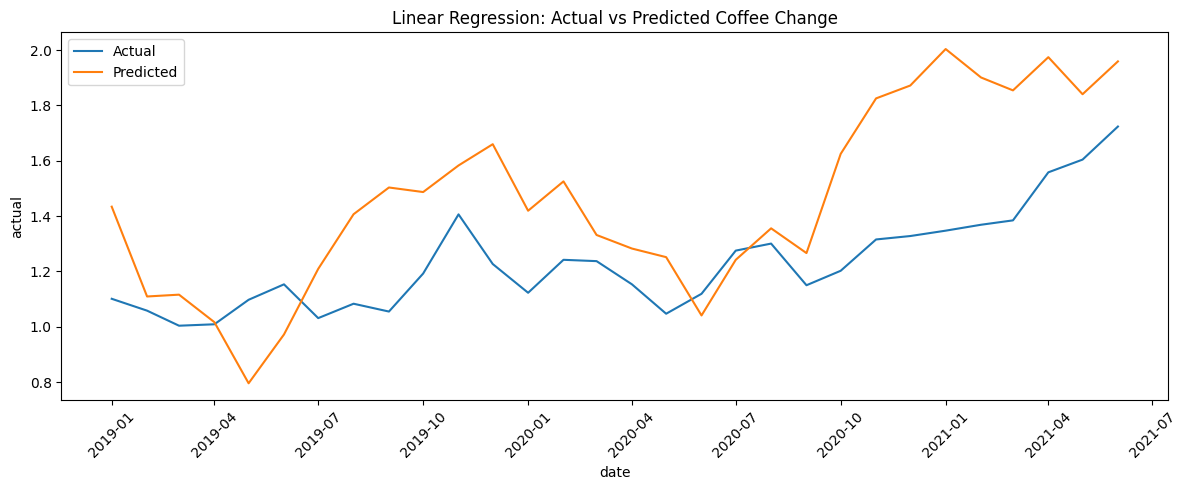

In [59]:
results_lr = pd.DataFrame({
    "date": dates_test,
    "actual": y_test.values,
    "predicted": lr_pred
})

plt.figure(figsize=(12, 5))
sns.lineplot(data=results_lr, x="date", y="actual", label="Actual")
sns.lineplot(data=results_lr, x="date", y="predicted", label="Predicted")
plt.title("Linear Regression: Actual vs Predicted Coffee Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
3,oilD_lag3,0.151994
0,oilD,0.113981
7,vietnam_precip_mean,0.075424
11,vietnam_precip_lag1,0.037677
15,vietnam_precip_lag2,0.024534
2,oilD_lag2,0.019930
12,brazil_temp_lag2,0.017155
19,vietnam_precip_lag3,-0.012739
16,brazil_temp_lag3,-0.023922
1,oilD_lag1,-0.028077


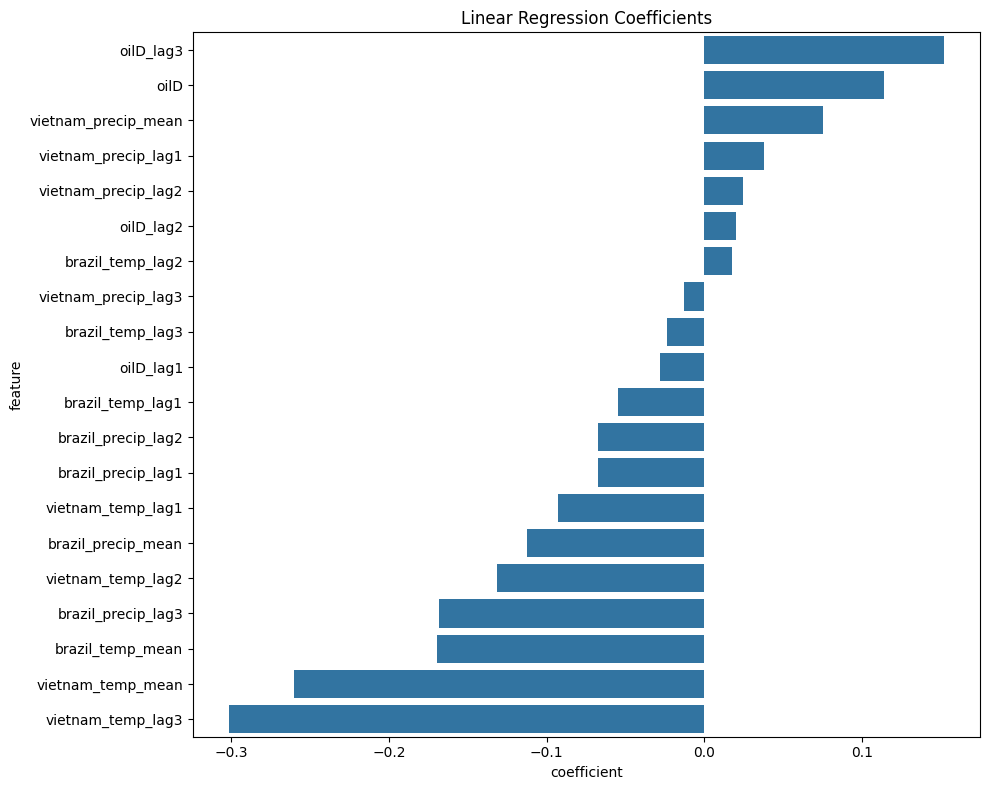

In [61]:
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x="coefficient", y="feature")
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()

# Ridge Regression Model

In [62]:
tscv = TimeSeriesSplit(n_splits=5)

ridge = Ridge()
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=tscv,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best CV score:", ridge_grid.best_score_)

Best Ridge alpha: {'alpha': 100}
Best CV score: -4.481177672317203


In [63]:
ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test_scaled)

print("Ridge Results")
print("R²:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge Results
R²: -2.333907014991828
MAE: 0.2824073729517446
RMSE: 0.32269768913806557


# Lasso Regression Model

In [64]:
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1.0]}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=tscv,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best CV score:", lasso_grid.best_score_)

Best Lasso alpha: {'alpha': 0.1}
Best CV score: -5.20796701392145


In [65]:
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test_scaled)

print("Lasso Results")
print("R²:", r2_score(y_test, lasso_pred))
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso Results
R²: -3.4716511094190583
MAE: 0.3254786027989785
RMSE: 0.37372579088989905


In [66]:
lasso_coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lasso_best.coef_
}).sort_values("coefficient", ascending=False)

lasso_coef_df

,feature,coefficient
0,oilD,0.174447
3,oilD_lag3,0.050725
1,oilD_lag1,0.016518
2,oilD_lag2,0.000000
4,brazil_temp_mean,-0.000000
5,brazil_precip_mean,0.000000
6,vietnam_temp_mean,-0.000000
7,vietnam_precip_mean,-0.000000
8,brazil_temp_lag1,-0.000000
9,brazil_precip_lag1,0.000000


# Random Forest Model

In [67]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("R²:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
R²: -3.158681543849476
MAE: 0.3269907677007673
RMSE: 0.3604100945849078


In [68]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

,feature,importance
3,oilD_lag3,0.251280
2,oilD_lag2,0.155316
0,oilD,0.102929
1,oilD_lag1,0.093029
9,brazil_precip_lag1,0.058565
5,brazil_precip_mean,0.044499
13,brazil_precip_lag2,0.038048
17,brazil_precip_lag3,0.037750
11,vietnam_precip_lag1,0.036983
19,vietnam_precip_lag3,0.031414


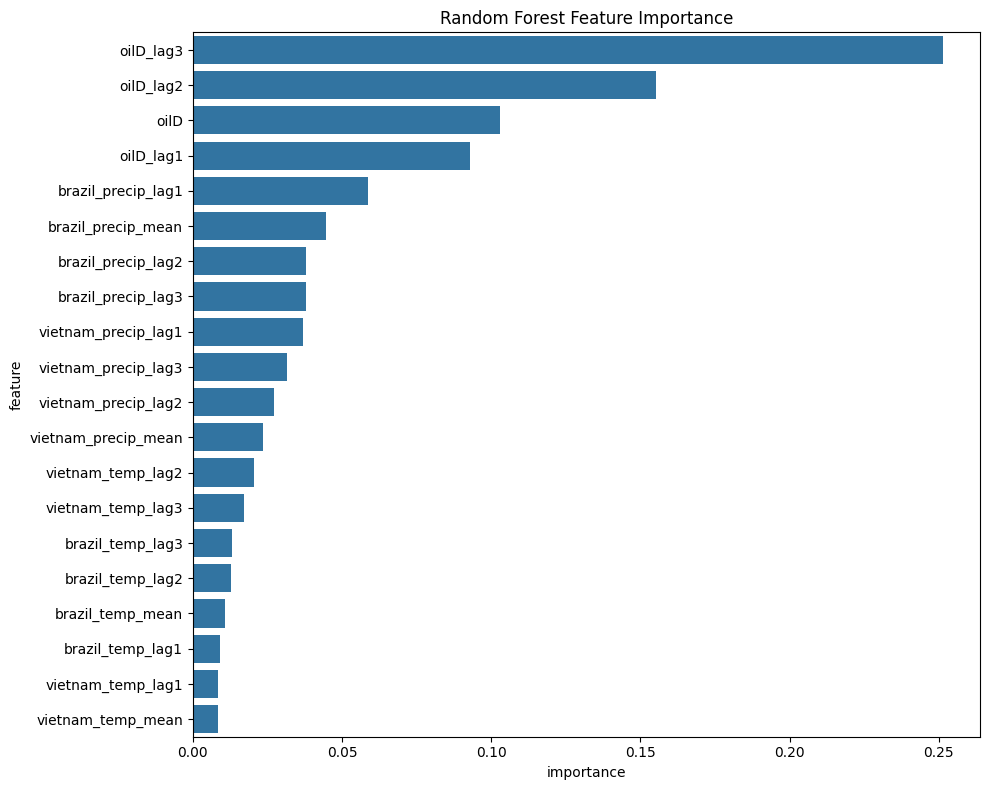

In [69]:
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [70]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Random Forest"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

model_results.sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
0,Linear Regression,-2.317248,0.271929,0.321890
1,Ridge,-2.333907,0.282407,0.322698
3,Random Forest,-3.158682,0.326991,0.360410
2,Lasso,-3.471651,0.325479,0.373726


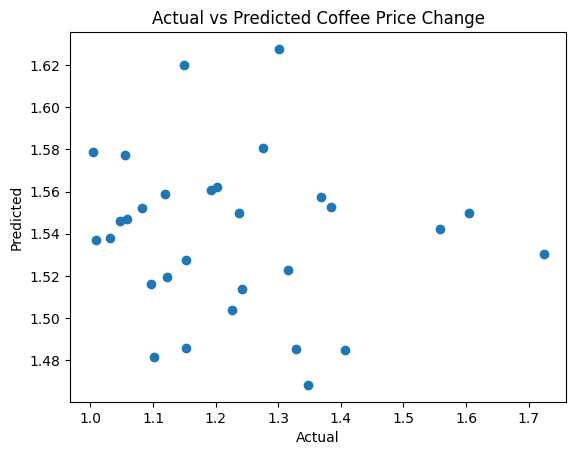

In [71]:
plt.scatter(y_test.values, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Coffee Price Change")
plt.show()

# Model Comparison 

In [82]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, r2, mae, rmse])

import pandas as pd

results_df = pd.DataFrame(results, columns=["Model","R2","MAE","RMSE"])
results_df

,Model,R2,MAE,RMSE
0,Linear,-0.337080,0.075325,0.091391
1,Ridge,-0.324322,0.074730,0.090954
2,Lasso,-0.034504,0.064676,0.080388
3,RandomForest,-0.241271,0.071533,0.088056


Monthly weather averages from Brazil/Vietnam do not strongly predict short-term coffee price changes.
Oil prices show moderate correlation with coffee price movements.